In [28]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis_tools as au

In [29]:
# ============================================================
# USER SETTINGS
# ============================================================

# Current iso-iso working point
MU_WP = 0.24
EGM_WP = 0.10

# Base event-level cuts
DPHI_CUT = 2.0
MJJ_CUT = 150.0
PIXEL_CUT = 3

# Scan settings
SCAN_MIN = 0.0
SCAN_MAX = 0.75
N_STEPS = 76

# Luminosity
LUMI = 59830.0

# Input paths
BACKGROUND_DIR = Path("./Updated-Background-JSONS")
SIGNAL_DIR = Path("./Updated-Signal-JSONS")
METADATA_PATH = Path("samples_metadata.pkl")

# Choose one signal sample for Asimov overlay.
# Option 1: choose by substring in sample_name
SIGNAL_SAMPLE_NAME_CONTAINS = None
# Example:
# SIGNAL_SAMPLE_NAME_CONTAINS = "2Mu2E_500GeV_0p25GeV_0p4mm"

# Option 2: if substring is None, use this index
SIGNAL_INDEX = 0

# Output directory
OUTDIR = Path("outputs/isoiso_abcd_1d_scans_three_panel")
OUTDIR.mkdir(parents=True, exist_ok=True)

print(f"Working point: muIso={MU_WP}, egmIso={EGM_WP}")
print(f"Base cuts: dPhi >= {DPHI_CUT}, mJJ >= {MJJ_CUT}, pixelCut <= {PIXEL_CUT}")
print(f"Output directory: {OUTDIR}")

Working point: muIso=0.24, egmIso=0.1
Base cuts: dPhi >= 2.0, mJJ >= 150.0, pixelCut <= 3
Output directory: outputs/isoiso_abcd_1d_scans_three_panel


In [30]:
backgrounds = au.load_samples(str(BACKGROUND_DIR))

print(f"Loaded {len(backgrounds)} background samples")
print("Background sample 0 keys:")
print(backgrounds[0].keys())

Loaded 15 background samples
Background sample 0 keys:
dict_keys(['dPhi', 'isolation', 'mJJ', 'egm_isolation', 'mu_lj_min_dxy', 'gen_weights', 'mu_lj_max_dxy', 'dsaMu_n', 'pfMu_n', 'pixelHits', 'trkHits', 'passing_weights', 'nevents', 'xsec'])


In [31]:
df_meta = pd.read_pickle(METADATA_PATH)

sample_ids = df_meta.loc[
    (slice(None), slice(None), slice(None), slice(None)),
    "sample_id"
].values

signal = au.load_samples(str(SIGNAL_DIR), sample_ids)

print(f"Loaded {len(signal)} signal samples")
print("Signal sample 0 keys:")
print(signal[0].keys())

Loaded 48 signal samples
Signal sample 0 keys:
dict_keys(['dPhi', 'isolation', 'egm_isolation', 'mu_lj_min_dxy', 'mu_lj_max_dxy', 'gen_weights', 'mJJ', 'dsaMu_n', 'pfMu_n', 'pixelHits', 'trkHits', 'passing_weights', 'sample_name', 'nevents', 'xsec'])


In [32]:
for i, sample in enumerate(signal):
    sample_name = sample.get("sample_name", f"signal_{i}")
    print(i, sample_name)

0 2Mu2E_200GeV_0p25GeV_0p1mm_info
1 2Mu2E_200GeV_1p2GeV_0p48mm_info
2 2Mu2E_200GeV_5p0GeV_2p0mm_info
3 2Mu2E_500GeV_0p25GeV_0p04mm_info
4 2Mu2E_500GeV_1p2GeV_0p19mm_info
5 2Mu2E_500GeV_5p0GeV_0p8mm_info
6 2Mu2E_800GeV_0p25GeV_0p025mm_info
7 2Mu2E_800GeV_1p2GeV_0p12mm_info
8 2Mu2E_800GeV_5p0GeV_0p5mm_info
9 2Mu2E_1000GeV_0p25GeV_0p02mm_info
10 2Mu2E_1000GeV_1p2GeV_0p096mm_info
11 2Mu2E_1000GeV_5p0GeV_0p4mm_info
12 2Mu2E_200GeV_0p25GeV_1p0mm_info
13 2Mu2E_200GeV_1p2GeV_4p8mm_info
14 2Mu2E_200GeV_5p0GeV_20p0mm_info
15 2Mu2E_500GeV_0p25GeV_0p4mm_info
16 2Mu2E_500GeV_1p2GeV_1p9mm_info
17 2Mu2E_500GeV_5p0GeV_8p0mm_info
18 2Mu2E_800GeV_0p25GeV_0p25mm_info
19 2Mu2E_800GeV_1p2GeV_1p2mm_info
20 2Mu2E_800GeV_5p0GeV_5p0mm_info
21 2Mu2E_1000GeV_0p25GeV_0p2mm_info
22 2Mu2E_1000GeV_1p2GeV_0p96mm_info
23 2Mu2E_1000GeV_5p0GeV_4p0mm_info
24 2Mu2E_200GeV_0p25GeV_5p0mm_info
25 2Mu2E_200GeV_1p2GeV_24p0mm_info
26 2Mu2E_200GeV_5p0GeV_100p0mm_info
27 2Mu2E_500GeV_0p25GeV_2p0mm_info
28 2Mu2E_500GeV_1p2GeV_9p6m

In [33]:
def choose_signal_sample(signal, name_contains=None, index=0):
    if name_contains is not None:
        for i, sample in enumerate(signal):
            sample_name = str(sample.get("sample_name", f"signal_{i}"))
            if name_contains in sample_name:
                print(f"Selected signal by name match:")
                print(f"  index = {i}")
                print(f"  sample_name = {sample_name}")
                return sample, i, sample_name

        raise ValueError(f"No signal sample name contained: {name_contains}")

    sample = signal[index]
    sample_name = str(sample.get("sample_name", f"signal_{index}"))

    print(f"Selected signal by index:")
    print(f"  index = {index}")
    print(f"  sample_name = {sample_name}")

    return sample, index, sample_name


signal_sample, signal_index, signal_name = choose_signal_sample(
    signal,
    name_contains=SIGNAL_SAMPLE_NAME_CONTAINS,
    index=12 ,
)

Selected signal by index:
  index = 12
  sample_name = 2Mu2E_200GeV_0p25GeV_1p0mm_info


In [34]:
def get_displacement_mask(sample, pixel_cut=3):
    pixel_hits = np.asarray(sample["pixelHits"], dtype=object)
    pixel_hits = np.where(pixel_hits == None, np.nan, pixel_hits).astype(float)

    pfmu_n = np.asarray(sample["pfMu_n"], dtype=float)
    dsamu_n = np.asarray(sample["dsaMu_n"], dtype=float)

    pixel_mask = np.where(np.isnan(pixel_hits), False, pixel_hits <= pixel_cut)

    displacement_mask = np.where(
        pfmu_n >= 1,
        pixel_mask,
        dsamu_n >= 1,
    )

    return displacement_mask


def get_scale(sample):
    return LUMI * float(sample.get("xsec", 0.0)) / float(sample.get("nevents", 1.0))


def isoiso_region_yield(
    sample,
    mu_iso_cut,
    egm_iso_cut,
    mu_iso_pass=True,
    egm_iso_pass=True,
    dphi_cut=2.0,
    mjj_cut=150.0,
    pixel_cut=3,
):
    """
    Iso-iso ABCD yield for one sample.

    Base cuts:
      dPhi >= dphi_cut
      mJJ >= mjj_cut
      displacement / pixel requirement

    ABCD axes:
      mu-LJ isolation: isolation
      egm-LJ isolation: egm_isolation

    Region flags:
      mu_iso_pass=True  means isolation <= mu_iso_cut
      mu_iso_pass=False means isolation >  mu_iso_cut

      egm_iso_pass=True  means egm_isolation <= egm_iso_cut
      egm_iso_pass=False means egm_isolation >  egm_iso_cut
    """

    mu_iso = np.asarray(sample["isolation"], dtype=float)
    egm_iso = np.asarray(sample["egm_isolation"], dtype=float)
    dphi = np.asarray(sample["dPhi"], dtype=float)
    mjj = np.asarray(sample["mJJ"], dtype=float)

    weights = np.asarray(sample["passing_weights"], dtype=float)
    scale = get_scale(sample)

    displacement_mask = get_displacement_mask(sample, pixel_cut=pixel_cut)

    mask = (
        np.isfinite(mu_iso)
        & np.isfinite(egm_iso)
        & np.isfinite(dphi)
        & np.isfinite(mjj)
        & (dphi >= dphi_cut)
        & (mjj >= mjj_cut)
        & displacement_mask
    )

    mu_pass_mask = mu_iso <= mu_iso_cut
    egm_pass_mask = egm_iso <= egm_iso_cut

    if mu_iso_pass:
        mask &= mu_pass_mask
    else:
        mask &= ~mu_pass_mask

    if egm_iso_pass:
        mask &= egm_pass_mask
    else:
        mask &= ~egm_pass_mask

    yld = scale * np.sum(weights[mask])
    var = scale * scale * np.sum(weights[mask] ** 2)

    return float(yld), float(var)


def get_isoiso_abcd_counts_for_sample(
    sample,
    mu_iso_cut,
    egm_iso_cut,
    dphi_cut=2.0,
    mjj_cut=150.0,
    pixel_cut=3,
):
    """
    Returns A/B/C/D counts for one sample.
    
    A: mu pass, egm pass
    B: mu fail, egm pass
    C: mu pass, egm fail
    D: mu fail, egm fail
    """

    region_defs = {
        "A": dict(mu_iso_pass=True,  egm_iso_pass=True),
        "B": dict(mu_iso_pass=False, egm_iso_pass=True),
        "C": dict(mu_iso_pass=True,  egm_iso_pass=False),
        "D": dict(mu_iso_pass=False, egm_iso_pass=False),
    }

    out = {}

    for region, flags in region_defs.items():
        yld, var = isoiso_region_yield(
            sample,
            mu_iso_cut=mu_iso_cut,
            egm_iso_cut=egm_iso_cut,
            dphi_cut=dphi_cut,
            mjj_cut=mjj_cut,
            pixel_cut=pixel_cut,
            **flags,
        )

        out[f"{region}Counts"] = yld
        out[f"{region}_Unc"] = np.sqrt(var)

    return out


def get_isoiso_abcd_counts_for_backgrounds(
    backgrounds,
    mu_iso_cut,
    egm_iso_cut,
    dphi_cut=2.0,
    mjj_cut=150.0,
    pixel_cut=3,
):
    """
    Total background A/B/C/D counts.
    """

    total = {
        "ACounts": 0.0,
        "BCounts": 0.0,
        "CCounts": 0.0,
        "DCounts": 0.0,
        "A_var": 0.0,
        "B_var": 0.0,
        "C_var": 0.0,
        "D_var": 0.0,
    }

    for sample in backgrounds:
        counts = get_isoiso_abcd_counts_for_sample(
            sample,
            mu_iso_cut=mu_iso_cut,
            egm_iso_cut=egm_iso_cut,
            dphi_cut=dphi_cut,
            mjj_cut=mjj_cut,
            pixel_cut=pixel_cut,
        )

        for region in ["A", "B", "C", "D"]:
            total[f"{region}Counts"] += counts[f"{region}Counts"]
            total[f"{region}_var"] += counts[f"{region}_Unc"] ** 2

    out = {
        "ACounts": total["ACounts"],
        "BCounts": total["BCounts"],
        "CCounts": total["CCounts"],
        "DCounts": total["DCounts"],
        "A_Unc": np.sqrt(total["A_var"]),
        "B_Unc": np.sqrt(total["B_var"]),
        "C_Unc": np.sqrt(total["C_var"]),
        "D_Unc": np.sqrt(total["D_var"]),
    }

    return out

In [46]:
def safe_ratio(num, den):
    if den == 0 or not np.isfinite(den):
        return np.nan
    return num / den


def ratio_uncertainty(ratio, num, num_unc, den, den_unc):
    if (
        not np.isfinite(ratio)
        or not np.isfinite(num)
        or not np.isfinite(num_unc)
        or not np.isfinite(den)
        or not np.isfinite(den_unc)
        or num <= 0
        or den <= 0
    ):
        return np.nan

    return abs(ratio) * np.sqrt(
        (num_unc / num) ** 2
        + (den_unc / den) ** 2
    )


def compute_abcd_metrics(counts):
    """
    Compute ABCD metrics using closure convention:

        closure = A_pred / A_obs

    Therefore:
        perfect closure = 1
        +/- 10% closure band = [0.9, 1.1]
    """

    A = counts["ACounts"]
    B = counts["BCounts"]
    C = counts["CCounts"]
    D = counts["DCounts"]

    A_unc = counts["A_Unc"]
    B_unc = counts["B_Unc"]
    C_unc = counts["C_Unc"]
    D_unc = counts["D_Unc"]

    out = dict(counts)

    # ABCD prediction
    if B > 0 and C > 0 and D > 0:
        pred = B * C / D
        pred_unc = pred * np.sqrt(
            (B_unc / B) ** 2
            + (C_unc / C) ** 2
            + (D_unc / D) ** 2
        )
    else:
        pred = np.nan
        pred_unc = np.nan

    # Closure convention: A_pred / A_obs
    if A > 0 and np.isfinite(pred):
        closure = pred / A
        closure_unc = closure * np.sqrt(
            (B_unc / B) ** 2
            + (C_unc / C) ** 2
            + (D_unc / D) ** 2
            + (A_unc / A) ** 2
        )
    else:
        closure = np.nan
        closure_unc = np.nan

    # Pull-like closure significance
    if np.isfinite(pred_unc):
        closure_sig = (A - pred) / np.sqrt(A_unc**2 + pred_unc**2)
    else:
        closure_sig = np.nan

    # Transfer factors
    tf_AC = safe_ratio(A, C)
    tf_BD = safe_ratio(B, D)
    tf_ratio = safe_ratio(tf_AC, tf_BD)

    tf_AC_unc = ratio_uncertainty(tf_AC, A, A_unc, C, C_unc)
    tf_BD_unc = ratio_uncertainty(tf_BD, B, B_unc, D, D_unc)

    out["prediction"] = pred
    out["predictionUnc"] = pred_unc

    out["closure"] = closure
    out["closureUnc"] = closure_unc
    out["closureSignificance"] = closure_sig

    out["tf_AC"] = tf_AC
    out["tf_AC_unc"] = tf_AC_unc
    out["tf_BD"] = tf_BD
    out["tf_BD_unc"] = tf_BD_unc
    out["tf_ratio"] = tf_ratio

    return out


def asimov_significance(s, b):
    if not np.isfinite(s) or not np.isfinite(b):
        return np.nan

    if s < 0 or b <= 0:
        return np.nan

    if s == 0:
        return 0.0

    term = (s + b) * np.log(1.0 + s / b) - s

    if term <= 0:
        return 0.0

    return np.sqrt(2.0 * term)

In [47]:
scan_values = np.linspace(SCAN_MIN, SCAN_MAX, N_STEPS)

print(scan_values[:5])
print(scan_values[-5:])

[0.   0.01 0.02 0.03 0.04]
[0.71 0.72 0.73 0.74 0.75]


In [48]:
def run_isoiso_1d_scan(
    backgrounds,
    signal_sample,
    scan_variable,
    scan_values,
    fixed_mu_iso,
    fixed_egm_iso,
    dphi_cut=2.0,
    mjj_cut=150.0,
    pixel_cut=3,
):
    """
    scan_variable:
      "mu"  -> scan muIsoCut while holding egmIsoCut fixed
      "egm" -> scan egmIsoCut while holding muIsoCut fixed
    """

    rows = []

    for cut in scan_values:
        if scan_variable == "mu":
            mu_cut = float(cut)
            egm_cut = float(fixed_egm_iso)
        elif scan_variable == "egm":
            mu_cut = float(fixed_mu_iso)
            egm_cut = float(cut)
        else:
            raise ValueError("scan_variable must be 'mu' or 'egm'")

        bkg_counts = get_isoiso_abcd_counts_for_backgrounds(
            backgrounds,
            mu_iso_cut=mu_cut,
            egm_iso_cut=egm_cut,
            dphi_cut=dphi_cut,
            mjj_cut=mjj_cut,
            pixel_cut=pixel_cut,
        )

        metrics = compute_abcd_metrics(bkg_counts)

        sig_counts = get_isoiso_abcd_counts_for_sample(
            signal_sample,
            mu_iso_cut=mu_cut,
            egm_iso_cut=egm_cut,
            dphi_cut=dphi_cut,
            mjj_cut=mjj_cut,
            pixel_cut=pixel_cut,
        )

        sig_A = sig_counts["ACounts"]
        bkg_A = metrics["ACounts"]

        asimov = asimov_significance(sig_A, bkg_A)

        sig_total = (
            sig_counts["ACounts"]
            + sig_counts["BCounts"]
            + sig_counts["CCounts"]
            + sig_counts["DCounts"]
        )

        signal_eff = sig_A / sig_total if sig_total > 0 else np.nan

        row = {
            "scan_variable": scan_variable,
            "scan_cut": float(cut),
            "muIsoCut": mu_cut,
            "egmIsoCut": egm_cut,
            "fixed_mu_iso": fixed_mu_iso,
            "fixed_egm_iso": fixed_egm_iso,
            "dPhiCut": dphi_cut,
            "mJJCut": mjj_cut,
            "pixelCut": pixel_cut,
            "signal_name": signal_name,
            "sig_A": sig_A,
            "sig_B": sig_counts["BCounts"],
            "sig_C": sig_counts["CCounts"],
            "sig_D": sig_counts["DCounts"],
            "signalEff": signal_eff,
            "AsimovSig": asimov,
        }

        row.update(metrics)
        rows.append(row)

    return pd.DataFrame(rows)

In [49]:
mu_scan_df = run_isoiso_1d_scan(
    backgrounds=backgrounds,
    signal_sample=signal_sample,
    scan_variable="mu",
    scan_values=scan_values,
    fixed_mu_iso=MU_WP,
    fixed_egm_iso=EGM_WP,
    dphi_cut=DPHI_CUT,
    mjj_cut=MJJ_CUT,
    pixel_cut=PIXEL_CUT,
)

mu_scan_df.to_csv(OUTDIR / "muIso_scan_fixed_egmIso.csv", index=False)

mu_scan_df.head()

,scan_variable,scan_cut,muIsoCut,egmIsoCut,fixed_mu_iso,fixed_egm_iso,dPhiCut,mJJCut,pixelCut,signal_name,...,prediction,predictionUnc,closure,closureUnc,closureSignificance,tf_AC,tf_AC_unc,tf_BD,tf_BD_unc,tf_ratio
0,mu,0.00,0.00,0.1,0.24,0.1,2.0,150.0,3,2Mu2E_200GeV_0p25GeV_1p0mm_info,...,0.078357,0.078899,30.122644,42.747671,-0.959629,0.003905,0.005501,0.117637,0.020182,0.033198
1,mu,0.01,0.01,0.1,0.24,0.1,2.0,150.0,3,2Mu2E_200GeV_0p25GeV_1p0mm_info,...,0.881909,0.537762,0.128035,0.112799,1.361038,0.909254,0.785478,0.116416,0.020130,7.810378
2,mu,0.02,0.02,0.1,0.24,0.1,2.0,150.0,3,2Mu2E_200GeV_0p25GeV_1p0mm_info,...,14.824920,14.047941,1.928850,2.139407,-0.484657,0.061723,0.067626,0.119054,0.020554,0.518444
3,mu,0.03,0.03,0.1,0.24,0.1,2.0,150.0,3,2Mu2E_200GeV_0p25GeV_1p0mm_info,...,30.222446,20.622151,2.786286,2.351329,-0.909059,0.043610,0.036022,0.121510,0.020996,0.358901
4,mu,0.04,0.04,0.1,0.24,0.1,2.0,150.0,3,2Mu2E_200GeV_0p25GeV_1p0mm_info,...,36.869931,21.574213,3.390021,2.598713,-1.168981,0.036235,0.027059,0.122838,0.021272,0.294983


In [50]:
egm_scan_df = run_isoiso_1d_scan(
    backgrounds=backgrounds,
    signal_sample=signal_sample,
    scan_variable="egm",
    scan_values=scan_values,
    fixed_mu_iso=MU_WP,
    fixed_egm_iso=EGM_WP,
    dphi_cut=DPHI_CUT,
    mjj_cut=MJJ_CUT,
    pixel_cut=PIXEL_CUT,
)

egm_scan_df.to_csv(OUTDIR / "egmIso_scan_fixed_muIso.csv", index=False)

egm_scan_df.head()

,scan_variable,scan_cut,muIsoCut,egmIsoCut,fixed_mu_iso,fixed_egm_iso,dPhiCut,mJJCut,pixelCut,signal_name,...,prediction,predictionUnc,closure,closureUnc,closureSignificance,tf_AC,tf_AC_unc,tf_BD,tf_BD_unc,tf_ratio
0,egm,0.00,0.24,0.00,0.24,0.1,2.0,150.0,3,2Mu2E_200GeV_0p25GeV_1p0mm_info,...,0.555017,0.331282,6.010734,7.000050,-1.345350,0.000079,0.000081,0.000476,0.000264,0.166369
1,egm,0.01,0.24,0.01,0.24,0.1,2.0,150.0,3,2Mu2E_200GeV_0p25GeV_1p0mm_info,...,4.830663,2.541981,0.276791,0.204935,1.337220,0.015195,0.008602,0.004206,0.002007,3.612834
2,egm,0.02,0.24,0.02,0.24,0.1,2.0,150.0,3,2Mu2E_200GeV_0p25GeV_1p0mm_info,...,21.711015,10.576048,0.983655,0.643501,0.025212,0.019295,0.009458,0.018979,0.008223,1.016617
3,egm,0.03,0.24,0.03,0.24,0.1,2.0,150.0,3,2Mu2E_200GeV_0p25GeV_1p0mm_info,...,39.133733,13.897334,1.225769,0.607039,-0.406394,0.028151,0.011592,0.034507,0.009493,0.815814
4,egm,0.04,0.24,0.04,0.24,0.1,2.0,150.0,3,2Mu2E_200GeV_0p25GeV_1p0mm_info,...,52.480994,16.886842,0.946209,0.418927,0.125001,0.049944,0.019014,0.047257,0.010681,1.056849


In [58]:
def _nice_step(raw_step):
    """
    Return a human-friendly tick step larger than or close to raw_step.
    Examples:
        0.53 -> 0.6
        0.91 -> 1.0
        1.34 -> 1.5
        2.2  -> 2.5
    """
    if not np.isfinite(raw_step) or raw_step <= 0:
        return 1.0

    exponent = np.floor(np.log10(raw_step))
    fraction = raw_step / (10 ** exponent)

    nice_fractions = np.array([1.0, 1.2, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0])
    nice_fraction = nice_fractions[nice_fractions >= fraction][0]

    return nice_fraction * (10 ** exponent)


def align_twin_yaxis_ticks_nice(
    ax_left,
    ax_right,
    right_values,
    left_ylim=(0, 3),
    right_min=0.0,
    n_ticks=7,
    pad=1.10,
):
    """
    Force left and right y-axis tick positions to line up exactly.

    Left axis:
        Uses linearly spaced ticks across left_ylim.

    Right axis:
        Uses the same number of ticks, starting from right_min,
        with a rounded/nice tick step chosen from the Asimov values.

    This avoids ugly labels like 0.590, 1.181, etc.
    """

    # Left axis ticks
    left_ticks = np.linspace(left_ylim[0], left_ylim[1], n_ticks)
    ax_left.set_ylim(*left_ylim)
    ax_left.set_yticks(left_ticks)

    # Right axis ticks
    right_values = np.asarray(right_values, dtype=float)
    finite = np.isfinite(right_values)

    if np.any(finite):
        right_max_data = np.nanmax(right_values[finite])
    else:
        right_max_data = 1.0

    right_max_padded = max(right_max_data * pad, 1e-9)

    raw_step = (right_max_padded - right_min) / (n_ticks - 1)
    step = _nice_step(raw_step)

    right_ticks = right_min + step * np.arange(n_ticks)
    right_ylim = (right_ticks[0], right_ticks[-1])

    ax_right.set_ylim(*right_ylim)
    ax_right.set_yticks(right_ticks)

    return left_ticks, right_ticks

In [80]:
def plot_three_panel_abcd_scan(
    df,
    scan_variable,
    selected_cut,
    fixed_cut,
    signal_name,
    outname,
    closure_ylim=(0, 3),
    tf_ylim=(0, 5),
    log_counts=False,
):
    """
    Makes a three-panel ABCD scan plot.

    Top:
      closure = A_pred / A_obs, with uncertainty
      perfect closure = 1
      +/- 10% closure bands = 0.9 and 1.1
      right y-axis: Asimov significance in red
      right y-axis uses the exact same numerical scale as the left axis

    Middle:
      transfer factors A/C and B/D with uncertainty

    Bottom:
      A/B/C/D background counts with uncertainty
    """

    df = df.copy().sort_values("scan_cut")
    x = df["scan_cut"].to_numpy(dtype=float)

    if scan_variable == "mu":
        xlabel = r"$\mu$-LJ isolation cut"
        fixed_label = rf"fixed $e/\gamma$-LJ iso = {fixed_cut:.3f}"
        selected_label = rf"selected $\mu$-LJ iso = {selected_cut:.3f}"
    elif scan_variable == "egm":
        xlabel = r"$e/\gamma$-LJ isolation cut"
        fixed_label = rf"fixed $\mu$-LJ iso = {fixed_cut:.3f}"
        selected_label = rf"selected $e/\gamma$-LJ iso = {selected_cut:.3f}"
    else:
        raise ValueError("scan_variable must be 'mu' or 'egm'")

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 12),
        sharex=True,
        gridspec_kw={"height_ratios": [1.2, 1.0, 1.2]},
    )

    # ========================================================
    # Top panel: closure + Asimov on second y axis
    # ========================================================

    ax = axes[0]

    closure = df["closure"].to_numpy(dtype=float)
    closure_unc = df["closureUnc"].to_numpy(dtype=float)

    mask = np.isfinite(x) & np.isfinite(closure) & np.isfinite(closure_unc)

    ax.errorbar(
        x[mask],
        closure[mask],
        yerr=closure_unc[mask],
        marker="o",
        linestyle="-",
        capsize=2,
        label=r"Closure ($A_{\mathrm{pred}}/A_{\mathrm{obs}}$)",
    )

    # Perfect closure and +/- 10% bands
    ax.axhline(1.0, linestyle="--", linewidth=1.2, label="Perfect closure")
    ax.axhline(1.1, linestyle=":", linewidth=1.2, label=r"$\pm 10\%$")
    ax.axhline(0.9, linestyle=":", linewidth=1.2)

    #ax.axvline(selected_cut, linestyle="--", linewidth=1.2, label=selected_label)

    ax.set_ylabel(r"Closure: $A_{\mathrm{pred}}/A_{\mathrm{obs}}$")
    ax.set_ylim(*closure_ylim)
    ax.grid(True, alpha=0.3)

    # Right axis: Asimov significance in red
    ax2 = ax.twinx()

    asimov = df["AsimovSig"].to_numpy(dtype=float)
    mask_sig = np.isfinite(x) & np.isfinite(asimov)

    ax2.plot(
        x[mask_sig],
        asimov[mask_sig],
        marker="s",
        linestyle="-",
        color="red",
        linewidth=1.8,
        markersize=5,
        label="Asimov significance",
    )

    ax2.set_ylabel("Asimov significance", color="red")
    ax2.tick_params(axis="y", colors="red")

    # Force right axis to match left axis exactly:
    # left value 1 aligns with right value 1, etc.
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(ax.get_yticks())

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)

    # ========================================================
    # Middle panel: transfer factors
    # ========================================================

    ax = axes[1]

    tf_ac = df["tf_AC"].to_numpy(dtype=float)
    tf_ac_unc = df["tf_AC_unc"].to_numpy(dtype=float)

    tf_bd = df["tf_BD"].to_numpy(dtype=float)
    tf_bd_unc = df["tf_BD_unc"].to_numpy(dtype=float)

    mask_ac = np.isfinite(x) & np.isfinite(tf_ac) & np.isfinite(tf_ac_unc)
    mask_bd = np.isfinite(x) & np.isfinite(tf_bd) & np.isfinite(tf_bd_unc)

    ax.errorbar(
        x[mask_ac],
        tf_ac[mask_ac],
        yerr=tf_ac_unc[mask_ac],
        marker="o",
        linestyle="-",
        capsize=2,
        label="A/C",
    )

    ax.errorbar(
        x[mask_bd],
        tf_bd[mask_bd],
        yerr=tf_bd_unc[mask_bd],
        marker="s",
        linestyle="-",
        capsize=2,
        label="B/D",
    )

    #ax.axvline(selected_cut, linestyle="--", linewidth=1.2)
    ax.set_ylabel("Transfer factor")
    ax.set_ylim(*tf_ylim)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ========================================================
    # Bottom panel: A/B/C/D counts
    # ========================================================

    ax = axes[2]

    for region, marker in zip(["A", "B", "C", "D"], ["o", "s", "^", "D"]):
        count_col = f"{region}Counts"
        unc_col = f"{region}_Unc"

        y = df[count_col].to_numpy(dtype=float)
        yerr = df[unc_col].to_numpy(dtype=float)

        mask_region = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)

        ax.errorbar(
            x[mask_region],
            y[mask_region],
            yerr=yerr[mask_region],
            marker=marker,
            linestyle="-",
            capsize=2,
            label=region,
        )

    #ax.axvline(selected_cut, linestyle="--", linewidth=1.2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Background yield")

    if log_counts:
        ax.set_yscale("log")

    ax.legend(ncol=4)
    ax.grid(True, alpha=0.3)

    # ========================================================
    # Title and save
    # ========================================================

    title = (
        "Iso-Iso ABCD 1D Scan\n"
        f"{fixed_label}, "
        rf"$d\phi \geq {DPHI_CUT}$, "
        rf"$m_{{JJ}} \geq {MJJ_CUT}$, "
        f"pixelCut={PIXEL_CUT}\n"
        f"Signal overlay: {signal_name}"
    )

    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    png_path = OUTDIR / f"{outname}.png"
    pdf_path = OUTDIR / f"{outname}.pdf"

    fig.savefig(png_path, dpi=300)
    #fig.savefig(pdf_path)

    print(f"Saved: {png_path}")
    #print(f"Saved: {pdf_path}")

    plt.show()

In [72]:
FIXED_POINTS = [0.1, 0.2, 0.24, 0.25, 0.3, 0.4, 0.5]

print("Fixed points:", FIXED_POINTS)

Fixed points: [0.1, 0.2, 0.24, 0.25, 0.3, 0.4, 0.5]


In [73]:
mu_scan_dict = {}

for fixed_egm in FIXED_POINTS:
    print(f"Running muIso scan with fixed egmIso = {fixed_egm}")

    temp_df = run_isoiso_1d_scan(
        backgrounds=backgrounds,
        signal_sample=signal_sample,
        scan_variable="mu",
        scan_values=scan_values,
        fixed_mu_iso=MU_WP,
        fixed_egm_iso=fixed_egm,
        dphi_cut=DPHI_CUT,
        mjj_cut=MJJ_CUT,
        pixel_cut=PIXEL_CUT,
    )

    mu_scan_dict[fixed_egm] = temp_df

    temp_df.to_csv(
        OUTDIR / f"muIso_scan_fixed_egmIso_{fixed_egm:.2f}.csv",
        index=False,
    )

print("Done.")

Running muIso scan with fixed egmIso = 0.1
Running muIso scan with fixed egmIso = 0.2
Running muIso scan with fixed egmIso = 0.24
Running muIso scan with fixed egmIso = 0.25
Running muIso scan with fixed egmIso = 0.3
Running muIso scan with fixed egmIso = 0.4
Running muIso scan with fixed egmIso = 0.5
Done.


In [74]:
egm_scan_dict = {}

for fixed_mu in FIXED_POINTS:
    print(f"Running egmIso scan with fixed muIso = {fixed_mu}")

    temp_df = run_isoiso_1d_scan(
        backgrounds=backgrounds,
        signal_sample=signal_sample,
        scan_variable="egm",
        scan_values=scan_values,
        fixed_mu_iso=fixed_mu,
        fixed_egm_iso=EGM_WP,
        dphi_cut=DPHI_CUT,
        mjj_cut=MJJ_CUT,
        pixel_cut=PIXEL_CUT,
    )

    egm_scan_dict[fixed_mu] = temp_df

    temp_df.to_csv(
        OUTDIR / f"egmIso_scan_fixed_muIso_{fixed_mu:.2f}.csv",
        index=False,
    )

print("Done.")

Running egmIso scan with fixed muIso = 0.1
Running egmIso scan with fixed muIso = 0.2
Running egmIso scan with fixed muIso = 0.24
Running egmIso scan with fixed muIso = 0.25
Running egmIso scan with fixed muIso = 0.3
Running egmIso scan with fixed muIso = 0.4
Running egmIso scan with fixed muIso = 0.5
Done.


Plotting muIso scan for fixed egmIso = 0.1
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_muIso_scan_fixed_egmIso_0.10.png


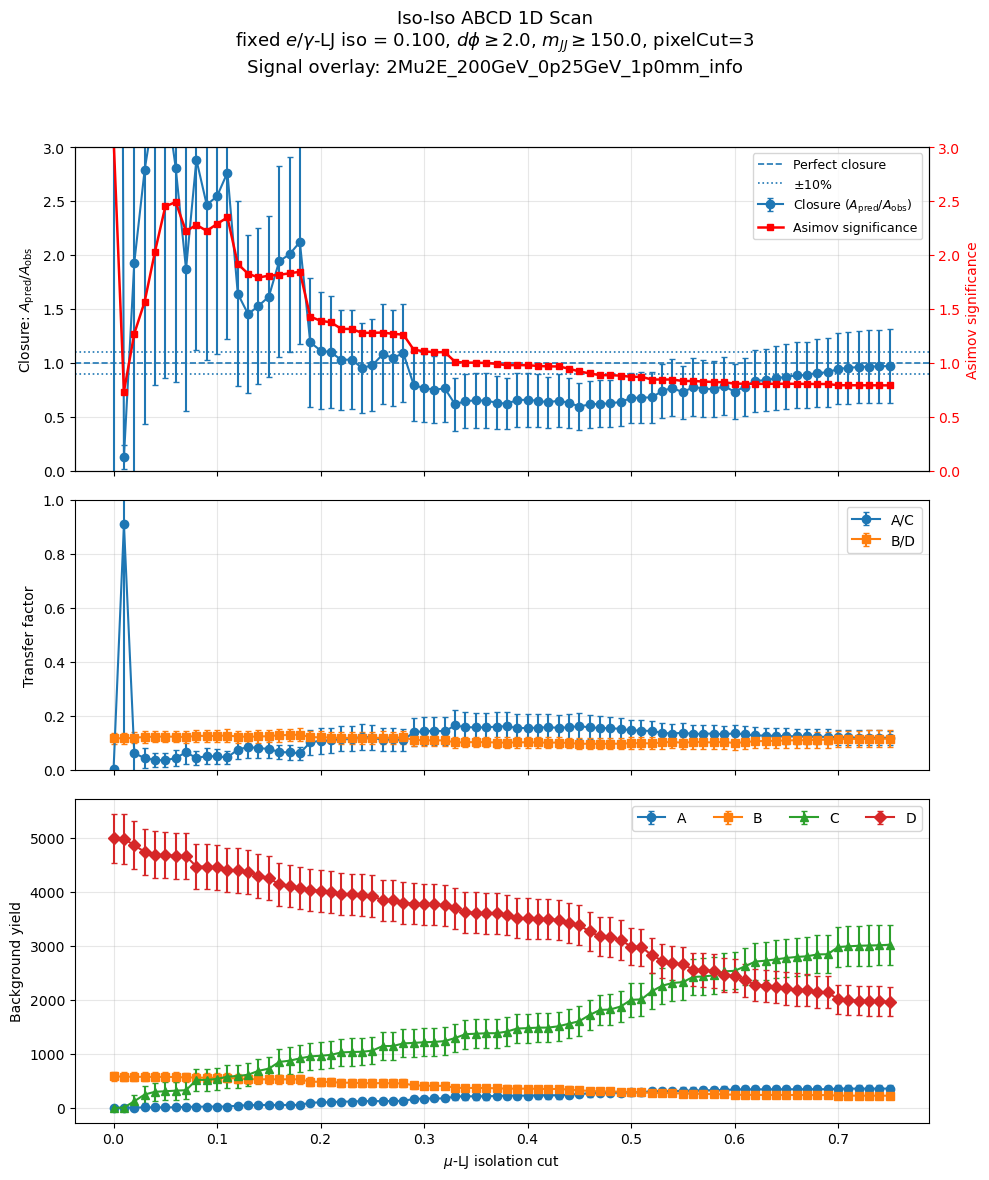

Plotting muIso scan for fixed egmIso = 0.2
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_muIso_scan_fixed_egmIso_0.20.png


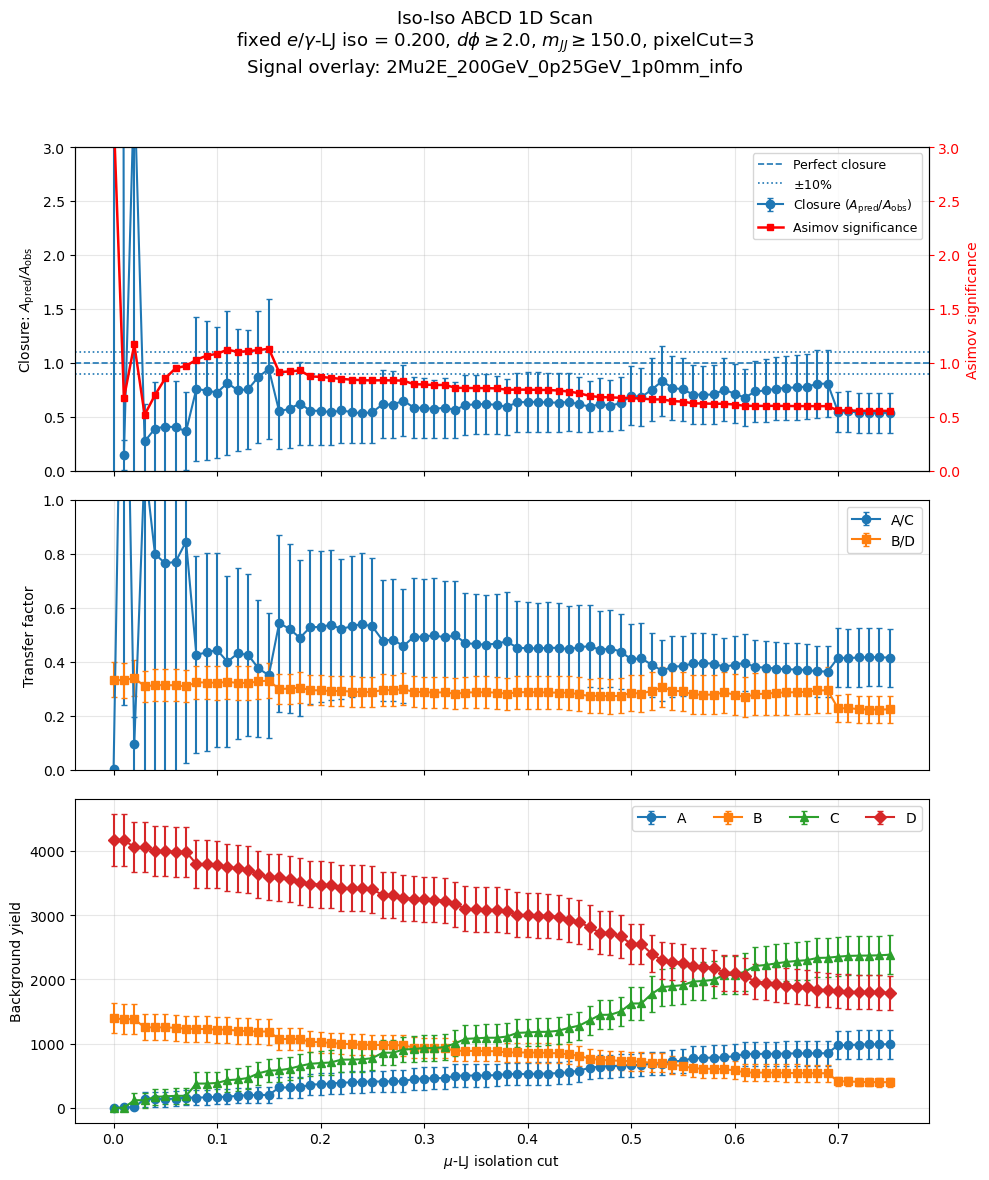

Plotting muIso scan for fixed egmIso = 0.24
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_muIso_scan_fixed_egmIso_0.24.png


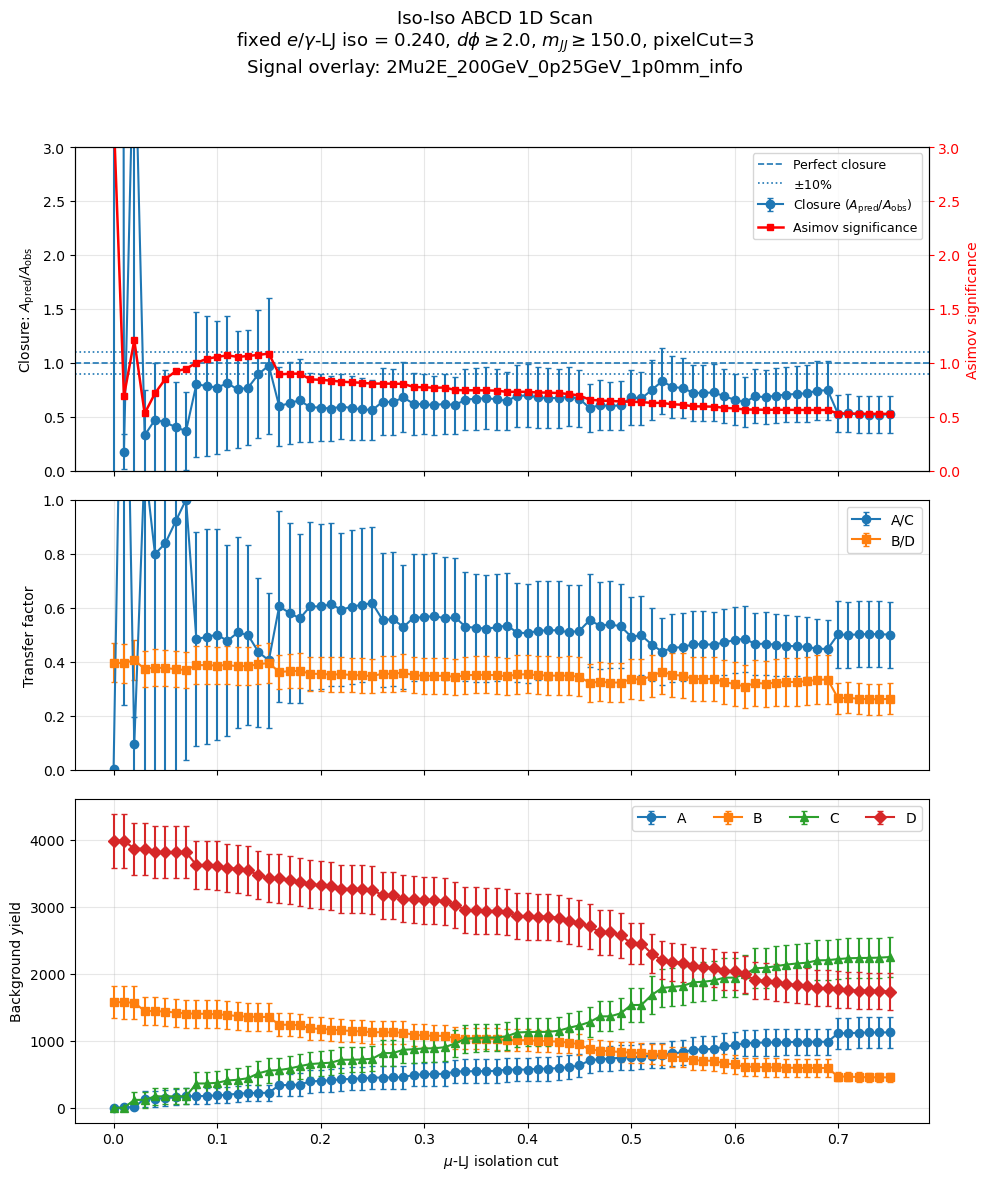

Plotting muIso scan for fixed egmIso = 0.25
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_muIso_scan_fixed_egmIso_0.25.png


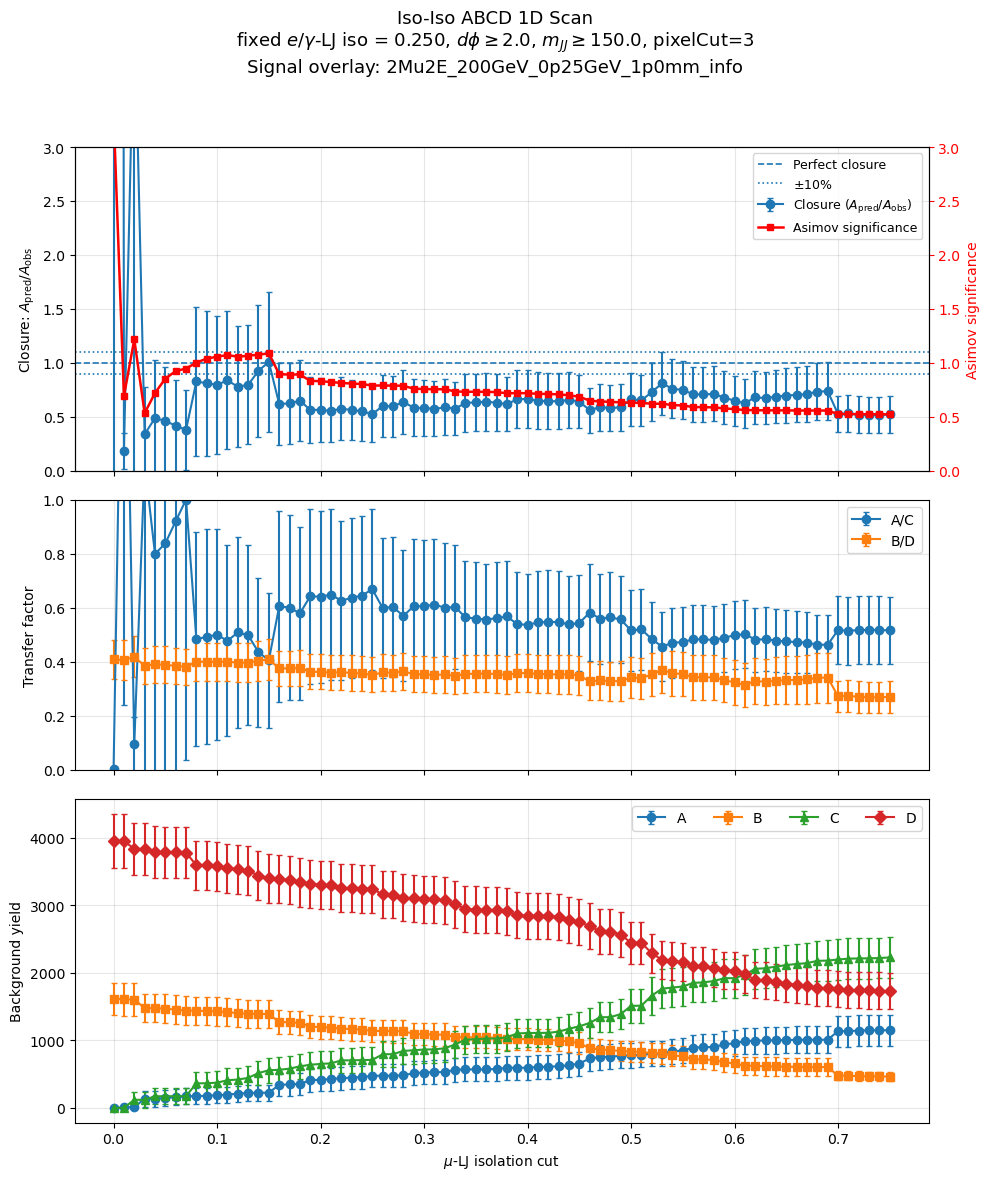

Plotting muIso scan for fixed egmIso = 0.3
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_muIso_scan_fixed_egmIso_0.30.png


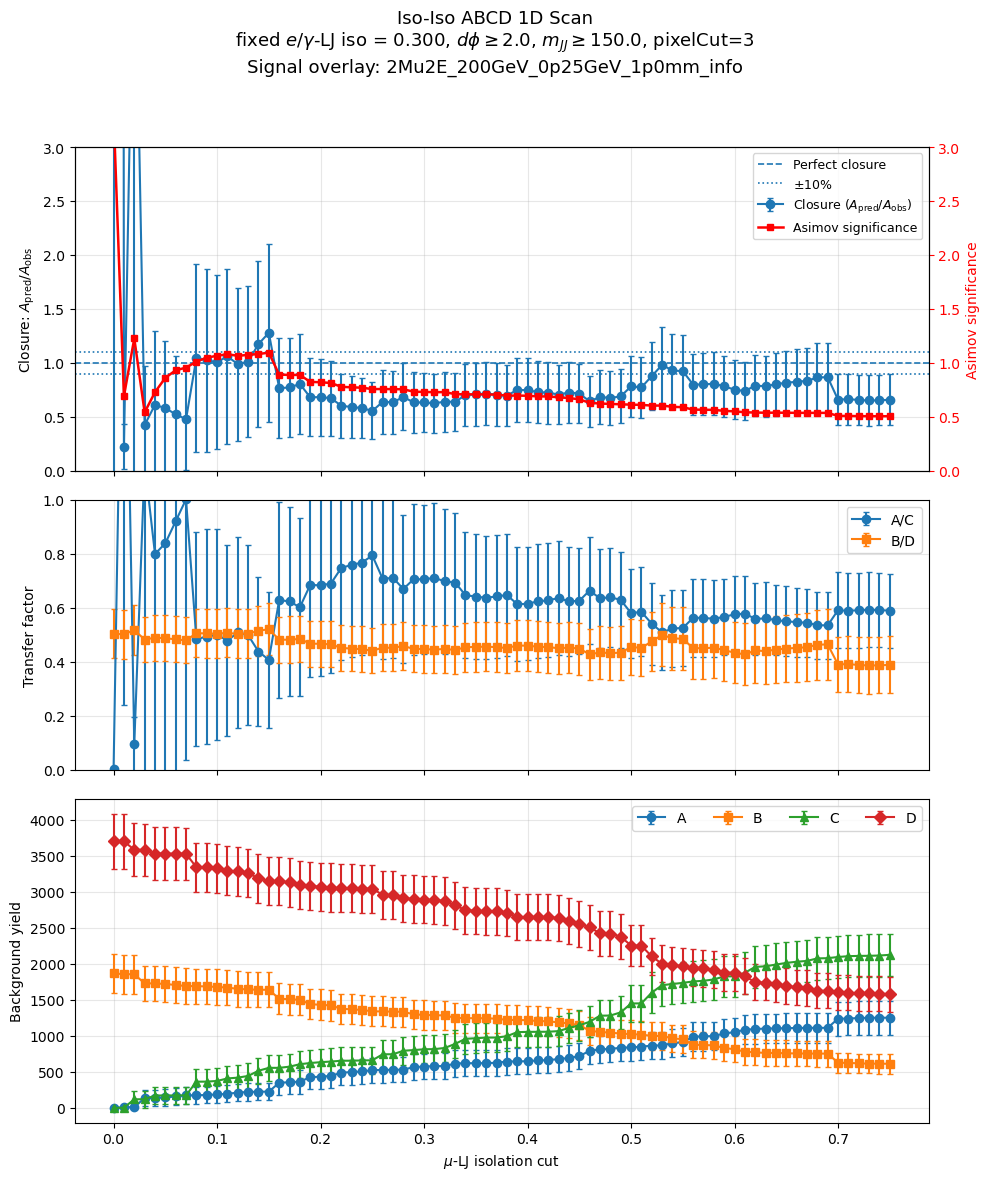

Plotting muIso scan for fixed egmIso = 0.4
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_muIso_scan_fixed_egmIso_0.40.png


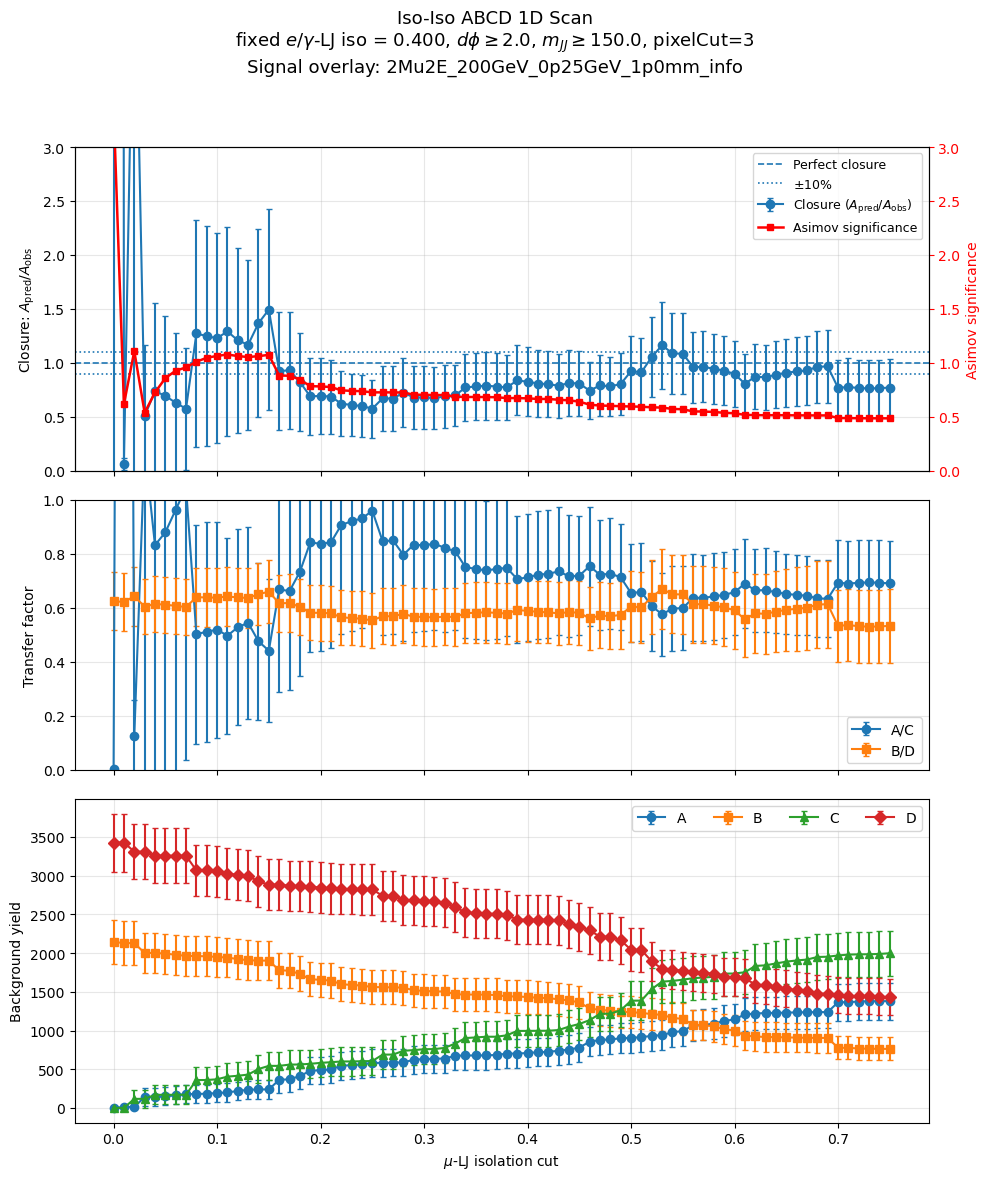

Plotting muIso scan for fixed egmIso = 0.5
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_muIso_scan_fixed_egmIso_0.50.png


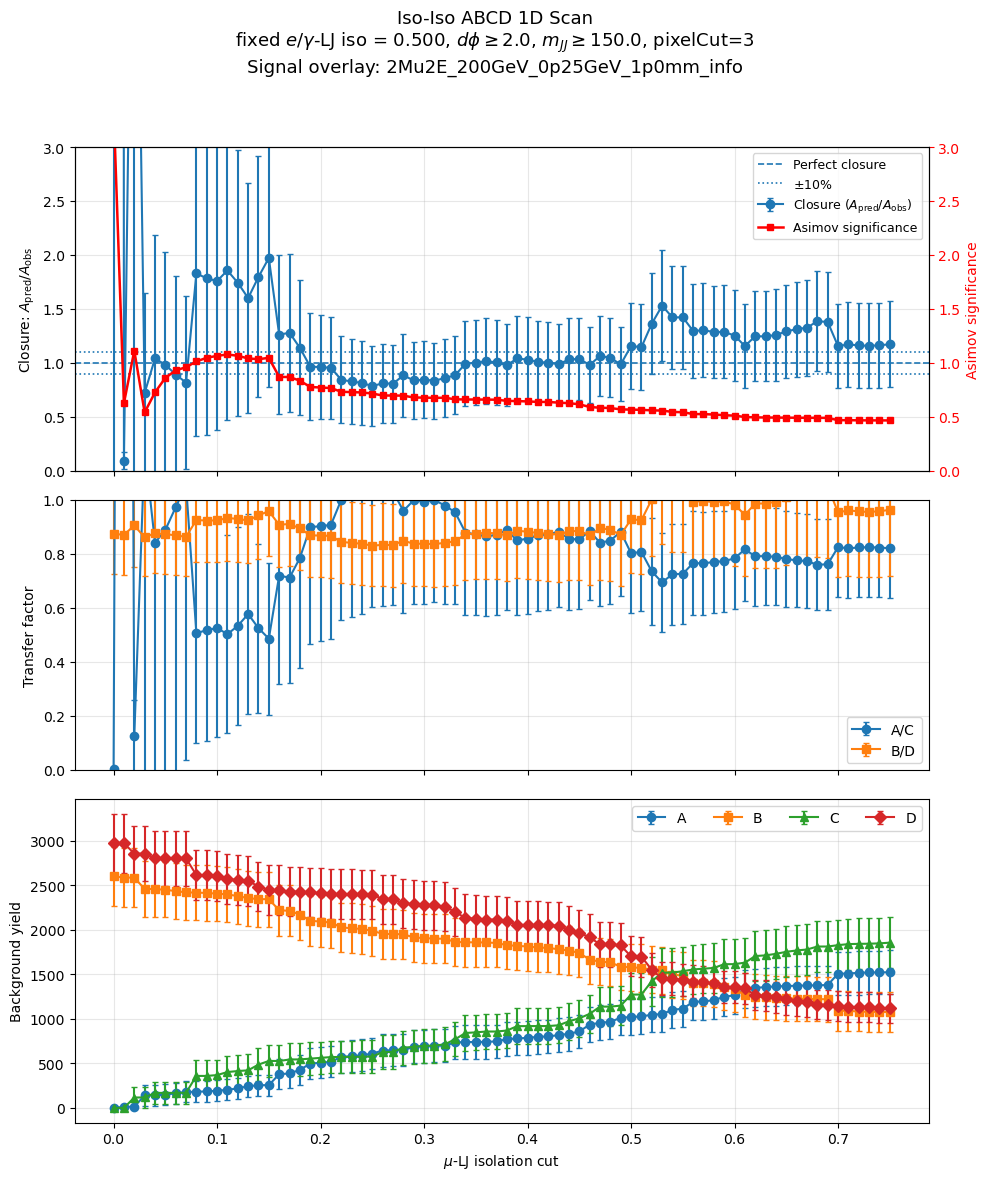

In [83]:
for fixed_egm in FIXED_POINTS:
    print(f"Plotting muIso scan for fixed egmIso = {fixed_egm}")

    temp_df = mu_scan_dict[fixed_egm]

    plot_three_panel_abcd_scan(
        df=temp_df,
        scan_variable="mu",
        selected_cut=MU_WP,
        fixed_cut=fixed_egm,
        signal_name=signal_name,
        outname=f"three_panel_muIso_scan_fixed_egmIso_{fixed_egm:.2f}",
        closure_ylim=(0, 3),
        tf_ylim=(0, 1),
        log_counts=False,
    )

Plotting egmIso scan for fixed muIso = 0.1
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_egmIso_scan_fixed_muIso_0.10.png


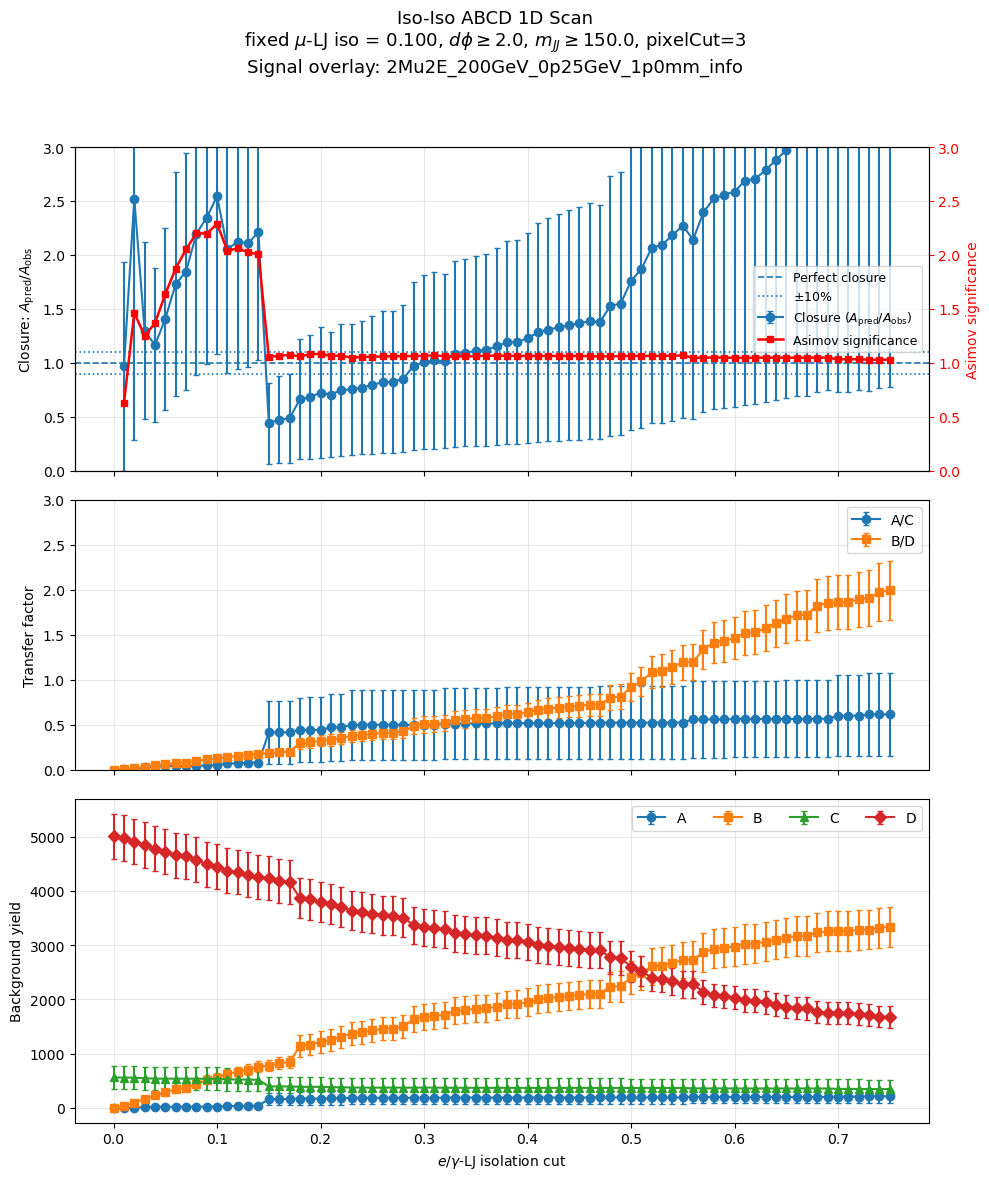

Plotting egmIso scan for fixed muIso = 0.2
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_egmIso_scan_fixed_muIso_0.20.png


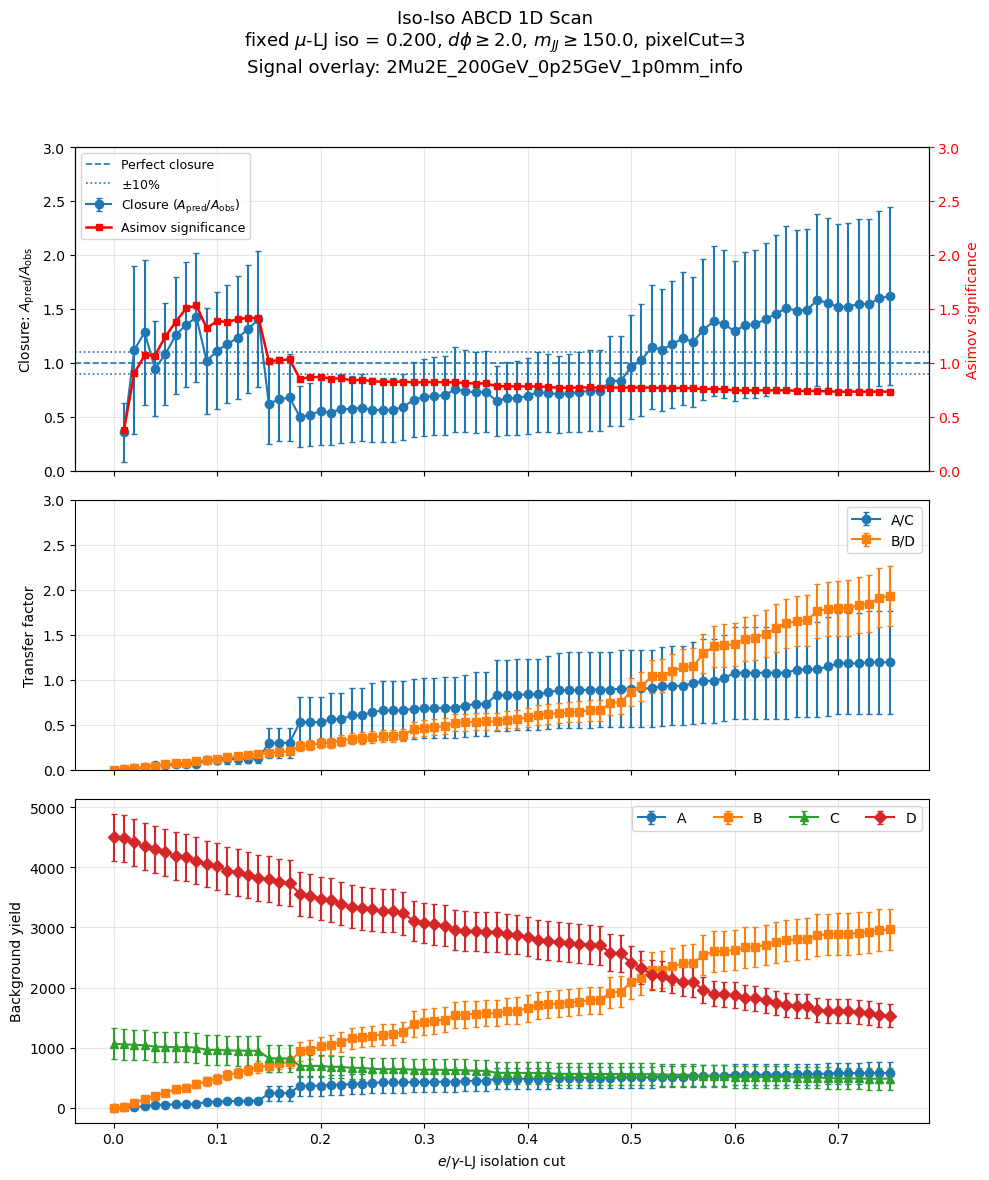

Plotting egmIso scan for fixed muIso = 0.24
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_egmIso_scan_fixed_muIso_0.24.png


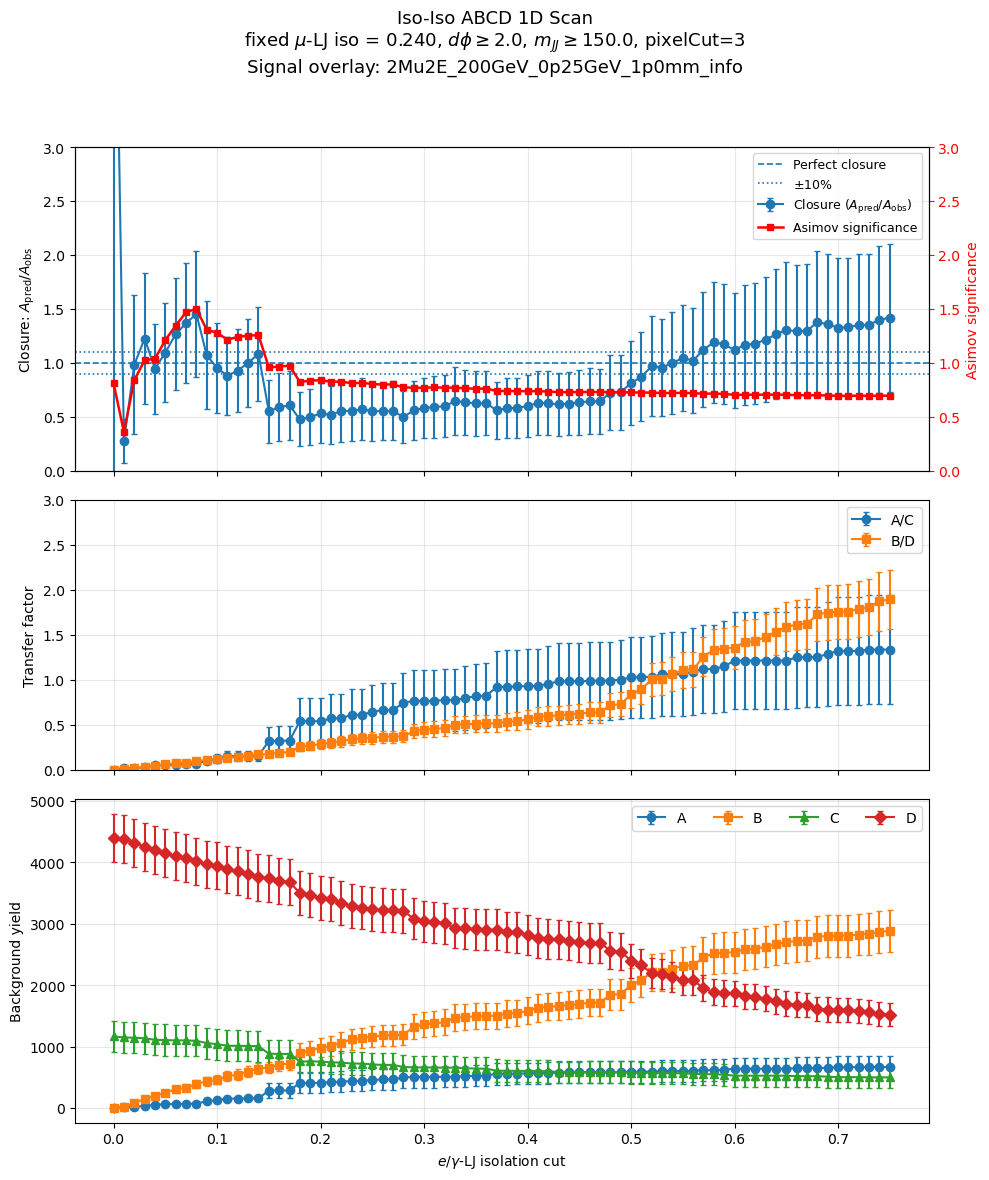

Plotting egmIso scan for fixed muIso = 0.25
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_egmIso_scan_fixed_muIso_0.25.png


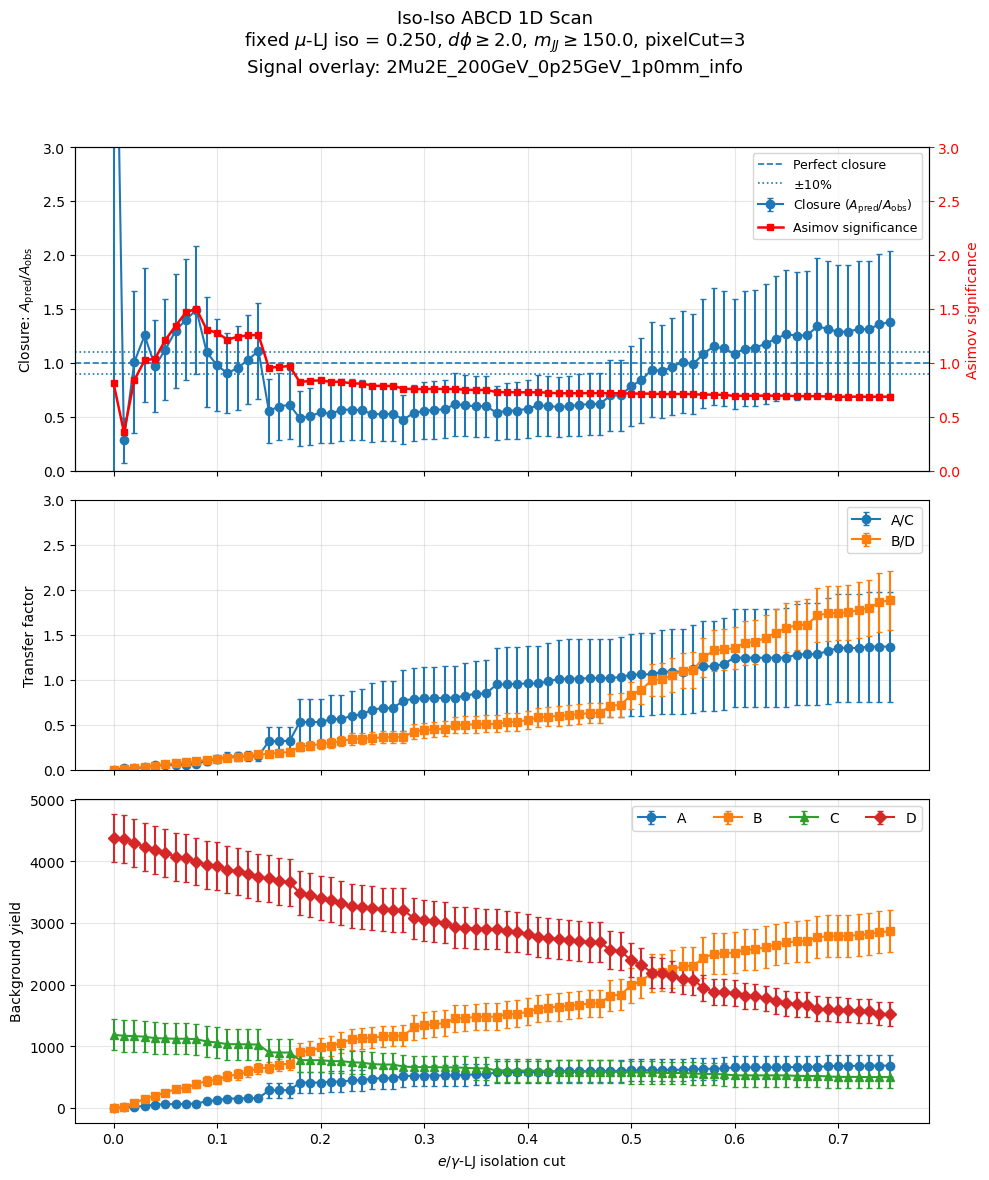

Plotting egmIso scan for fixed muIso = 0.3
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_egmIso_scan_fixed_muIso_0.30.png


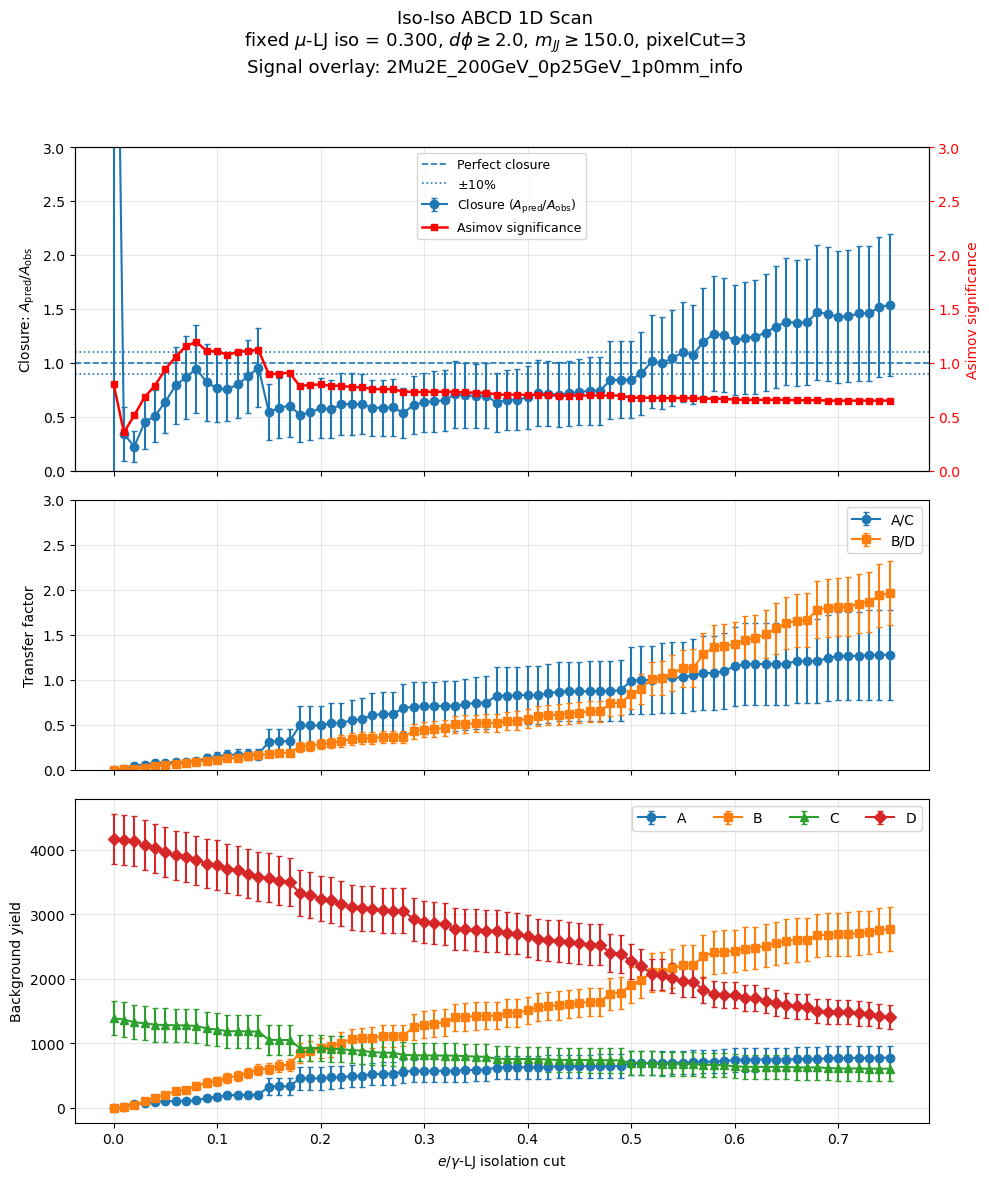

Plotting egmIso scan for fixed muIso = 0.4
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_egmIso_scan_fixed_muIso_0.40.png


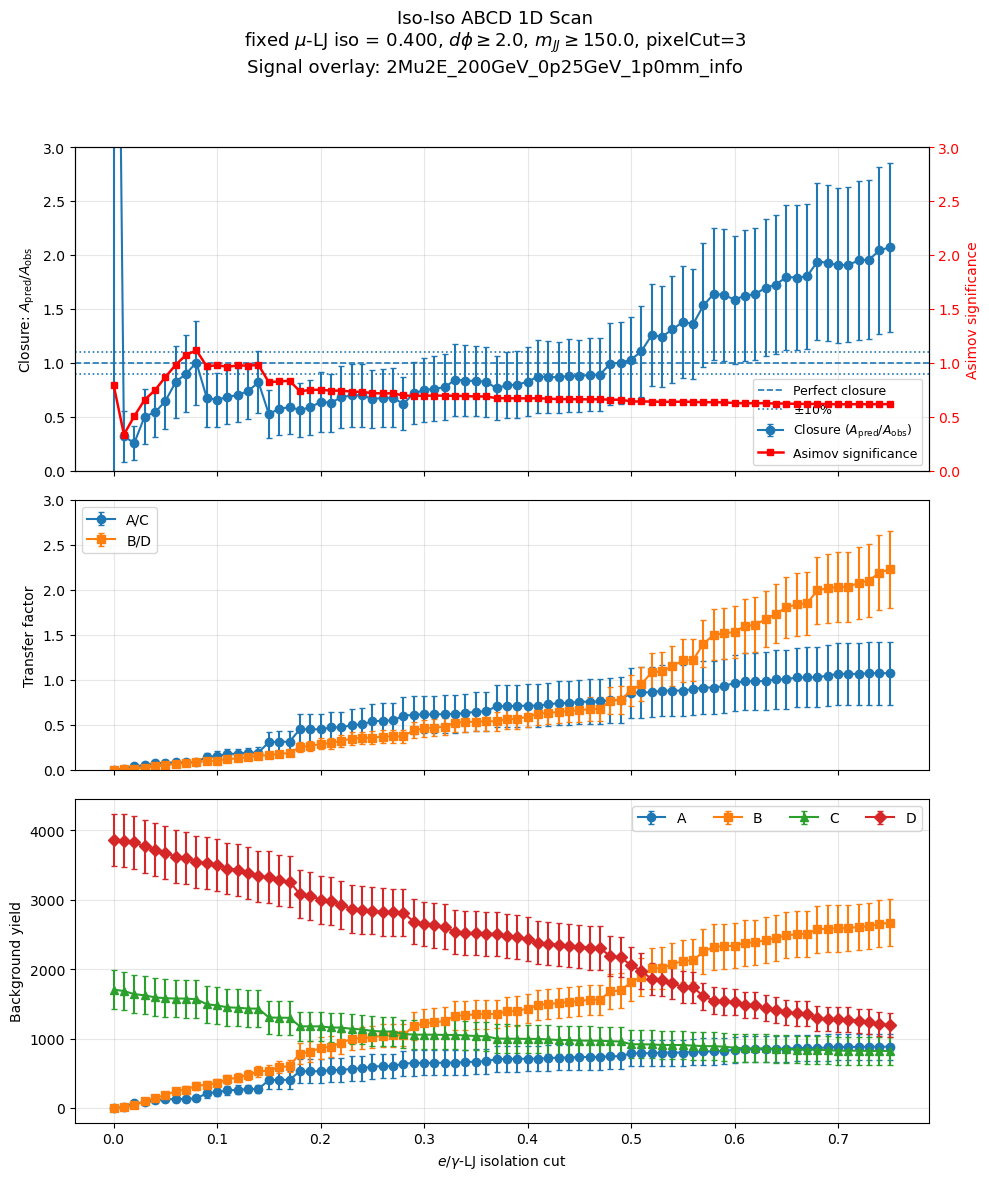

Plotting egmIso scan for fixed muIso = 0.5
Saved: outputs/isoiso_abcd_1d_scans_three_panel/three_panel_egmIso_scan_fixed_muIso_0.50.png


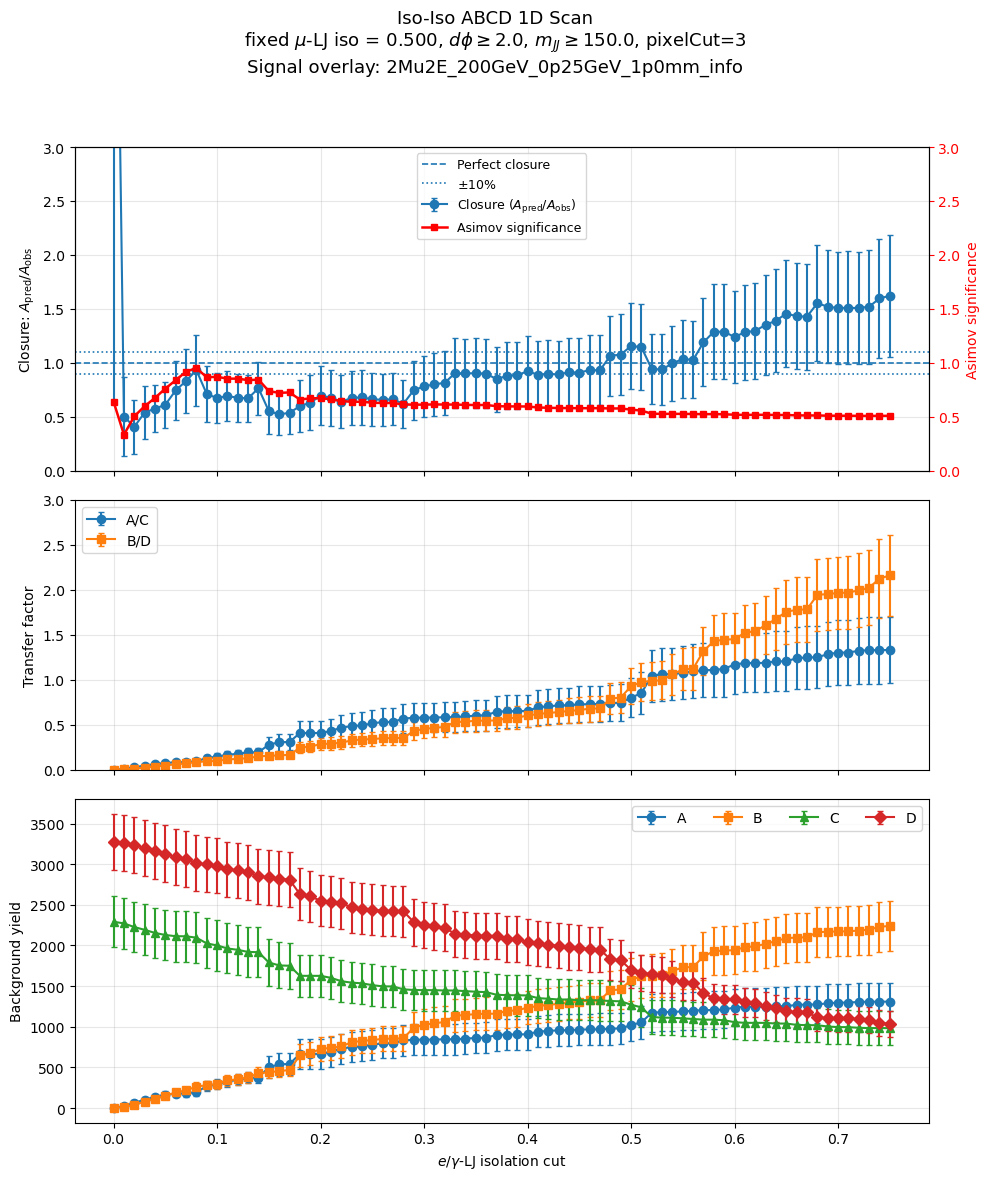

In [84]:
for fixed_mu in FIXED_POINTS:
    print(f"Plotting egmIso scan for fixed muIso = {fixed_mu}")

    temp_df = egm_scan_dict[fixed_mu]

    plot_three_panel_abcd_scan(
        df=temp_df,
        scan_variable="egm",
        selected_cut=EGM_WP,
        fixed_cut=fixed_mu,
        signal_name=signal_name,
        outname=f"three_panel_egmIso_scan_fixed_muIso_{fixed_mu:.2f}",
        closure_ylim=(0, 3),
        tf_ylim=(0, 3),
        log_counts=False,
    )